In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from blimpy import Waterfall


PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "voyager" / "Voyager1.single_coarse.fine_res.h5"

print("Notebook running from:", Path.cwd())
print("Data path:", DATA_PATH)
print("File exists:", DATA_PATH.exists())

Notebook running from: /Users/parthshringarpure/deepseti/notebooks
Data path: /Users/parthshringarpure/deepseti/data/raw/voyager/Voyager1.single_coarse.fine_res.h5
File exists: True


/Users/parthshringarpure/deepseti/.venv/lib/python3.12/site-packages/blimpy/__init__.py:21: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
wf = Waterfall(str(DATA_PATH))

print("Voyager file loaded successfully")
print("Raw data shape:", wf.data.shape)

Voyager file loaded successfully
Raw data shape: (16, 1, 1048576)


In [3]:
data = wf.data.squeeze()

print("Original shape:", wf.data.shape)
print("Simplified shape:", data.shape)

Original shape: (16, 1, 1048576)
Simplified shape: (16, 1048576)


In [4]:
slice_width = 4096 # how many frequency channels are we chooseig to look at first 

start_chan = data.shape[1] // 2
stop_chan = start_chan + slice_width

slice_data = data[:, start_chan:stop_chan]

print("Start channel:", start_chan)
print("Stop channel:", stop_chan)
print("Slice shape:", slice_data.shape)

Start channel: 524288
Stop channel: 528384
Slice shape: (16, 4096)


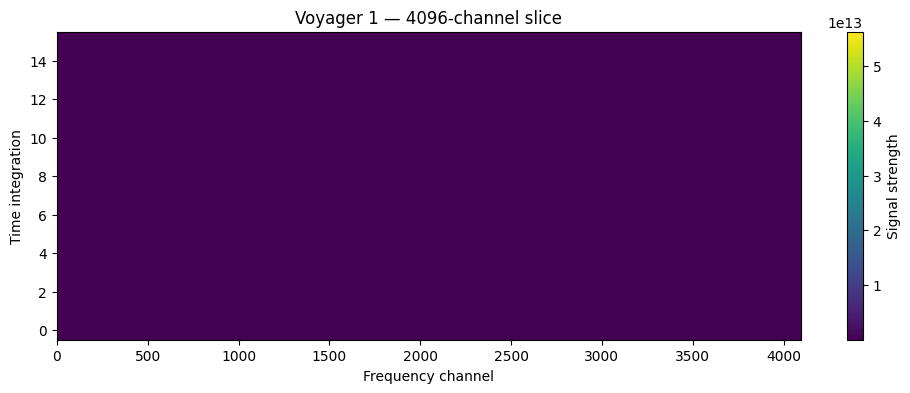

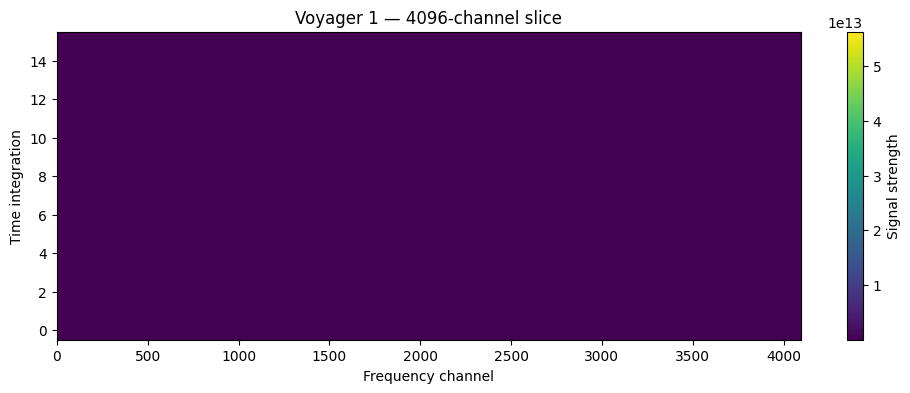

In [6]:
%matplotlib inline
plt.figure(figsize=(12, 4))

plt.imshow(
    slice_data,
    aspect="auto",
    origin="lower",
)

plt.xlabel("Frequency channel")
plt.ylabel("Time integration")
plt.title("Voyager 1 — 4096-channel slice")

plt.colorbar(label="Signal strength")

plt.show()

In [7]:
print("Minimum:", slice_data.min())
print("Maximum:", slice_data.max())
print("Mean:", slice_data.mean())

Minimum: 6.9113503e+09
Maximum: 5.6310045e+13
Mean: 2.4697102e+10


In [8]:
import numpy as np

log_slice = np.log10(slice_data)

print("Original range:")
print(slice_data.min(), "to", slice_data.max())

print("\nLog range:")
print(log_slice.min(), "to", log_slice.max())

Original range:
6.9113503e+09 to 5.6310045e+13

Log range:
9.839563 to 13.750586


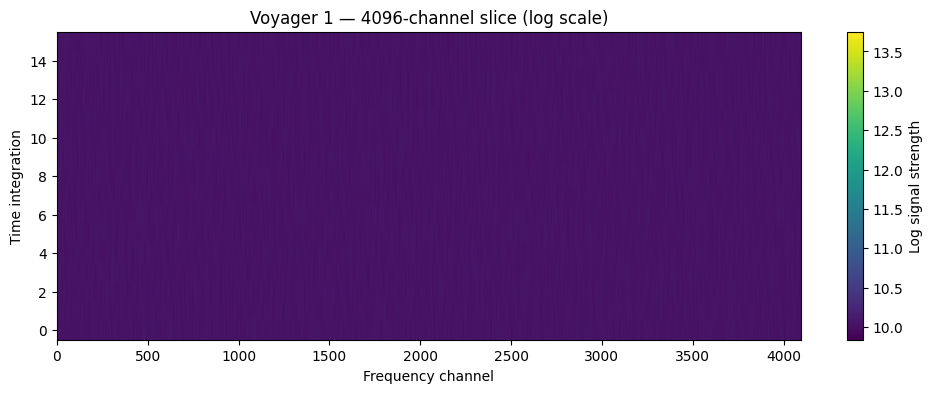

In [9]:
plt.figure(figsize=(12, 4))

plt.imshow(
    log_slice,
    aspect="auto",
    origin="lower",
)

plt.xlabel("Frequency channel")
plt.ylabel("Time integration")
plt.title("Voyager 1 — 4096-channel slice (log scale)")

plt.colorbar(label="Log signal strength")

plt.show()

In [10]:
mean_power = data.mean(axis=0)

strongest_channel = mean_power.argmax()

print("Strongest channel:", strongest_channel)
print("Average power there:", mean_power[strongest_channel])

Strongest channel: 524288
Average power there: 5.6088137e+13


In [11]:
half_width = 4096 // 2

start_chan = strongest_channel - half_width
stop_chan = strongest_channel + half_width

centered_slice = data[:, start_chan:stop_chan]

print("Start channel:", start_chan)
print("Strongest channel:", strongest_channel)
print("Stop channel:", stop_chan)
print("Slice shape:", centered_slice.shape)

Start channel: 522240
Strongest channel: 524288
Stop channel: 526336
Slice shape: (16, 4096)


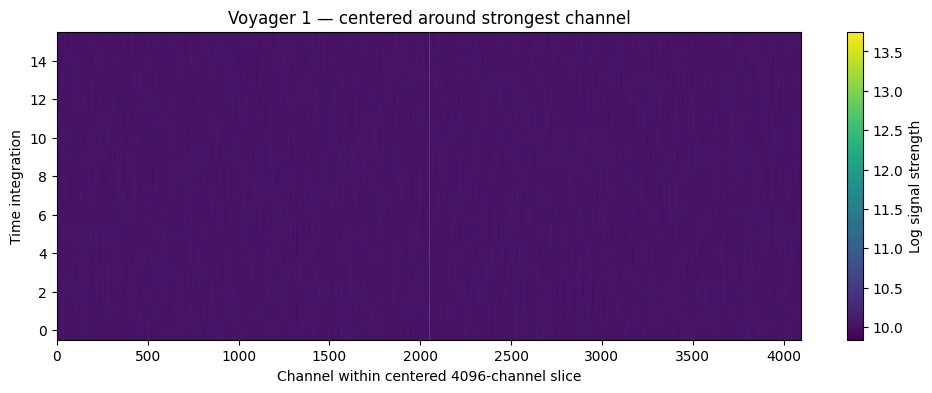

In [12]:
centered_log = np.log10(centered_slice)

plt.figure(figsize=(12, 4))

plt.imshow(
    centered_log,
    aspect="auto",
    origin="lower",
)

plt.xlabel("Channel within centered 4096-channel slice")
plt.ylabel("Time integration")
plt.title("Voyager 1 — centered around strongest channel")

plt.colorbar(label="Log signal strength")

plt.show()

In [13]:
target_freq_mhz = 8419.297

fch1 = wf.header["fch1"]
foff = wf.header["foff"]

target_channel = int(round((target_freq_mhz - fch1) / foff))

print("Target frequency:", target_freq_mhz, "MHz")
print("Corresponding channel:", target_channel)

Target frequency: 8419.297 MHz
Corresponding channel: 747939


In [14]:
half_width = 4096 // 2

voyager_start = target_channel - half_width
voyager_stop = target_channel + half_width

voyager_slice = data[:, voyager_start:voyager_stop]

print("Voyager-centered slice shape:", voyager_slice.shape)
print("Start channel:", voyager_start)
print("Target channel:", target_channel)
print("Stop channel:", voyager_stop)

Voyager-centered slice shape: (16, 4096)
Start channel: 745891
Target channel: 747939
Stop channel: 749987


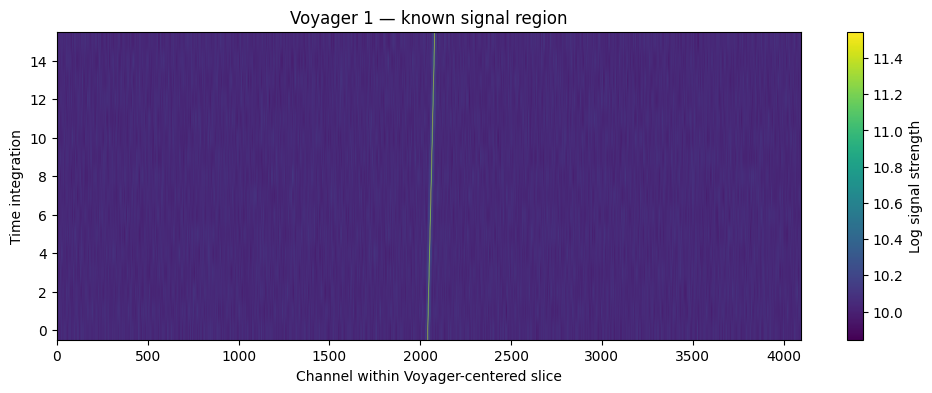

In [15]:
voyager_log = np.log10(voyager_slice)

plt.figure(figsize=(12, 4))

plt.imshow(
    voyager_log,
    aspect="auto",
    origin="lower",
)

plt.xlabel("Channel within Voyager-centered slice")
plt.ylabel("Time integration")
plt.title("Voyager 1 — known signal region")

plt.colorbar(label="Log signal strength")

plt.show()

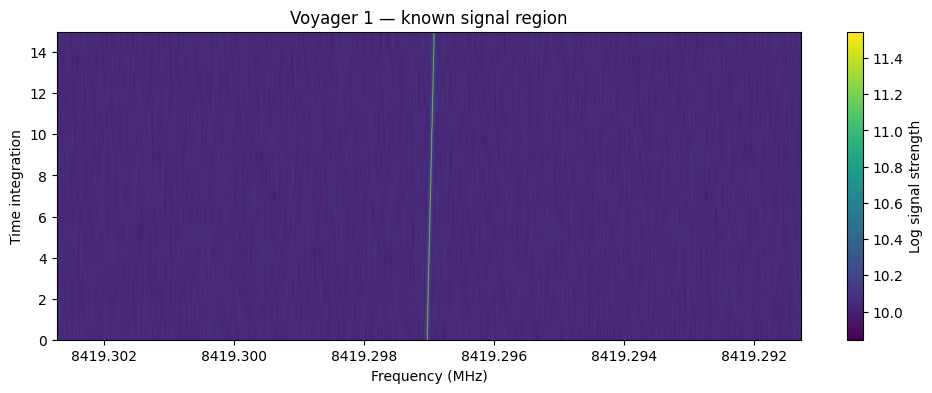

In [16]:
freqs_mhz = fch1 + np.arange(voyager_start, voyager_stop) * foff

plt.figure(figsize=(12, 4))

plt.imshow(
    voyager_log,
    aspect="auto",
    origin="lower",
    extent=[
        freqs_mhz[0],
        freqs_mhz[-1],
        0,
        voyager_log.shape[0] - 1,
    ],
)

plt.xlabel("Frequency (MHz)")
plt.ylabel("Time integration")
plt.title("Voyager 1 — known signal region")

plt.colorbar(label="Log signal strength")

plt.show()

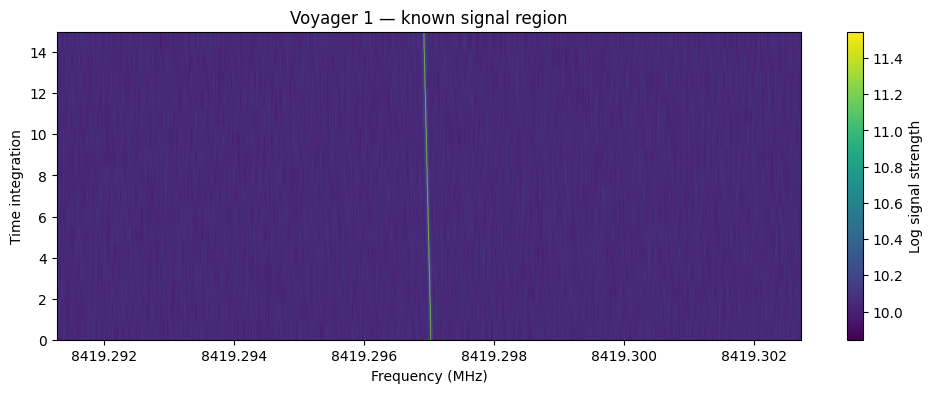

In [17]:
freqs_ascending = freqs_mhz[::-1]
voyager_log_ascending = voyager_log[:, ::-1]

plt.figure(figsize=(12, 4))

plt.imshow(
    voyager_log_ascending,
    aspect="auto",
    origin="lower",
    extent=[
        freqs_ascending[0],
        freqs_ascending[-1],
        0,
        voyager_log_ascending.shape[0] - 1,
    ],
)

plt.xlabel("Frequency (MHz)")
plt.ylabel("Time integration")
plt.title("Voyager 1 — known signal region")

plt.colorbar(label="Log signal strength")

plt.show()

In [ ]:
# row 0 = first ~18.25 seconds
# row 1 = next ~18.25 seconds
# row 2 = next ~18.25 seconds
# ...
# row 15 = final ~18.25 seconds



#           frequency →
# time ↓

# row 0   [ radio power at many frequencies ]
# row 1   [ radio power at many frequencies ]
# row 2   [ radio power at many frequencies ]
# ...
# row 15  [ radio power at many frequencies ]

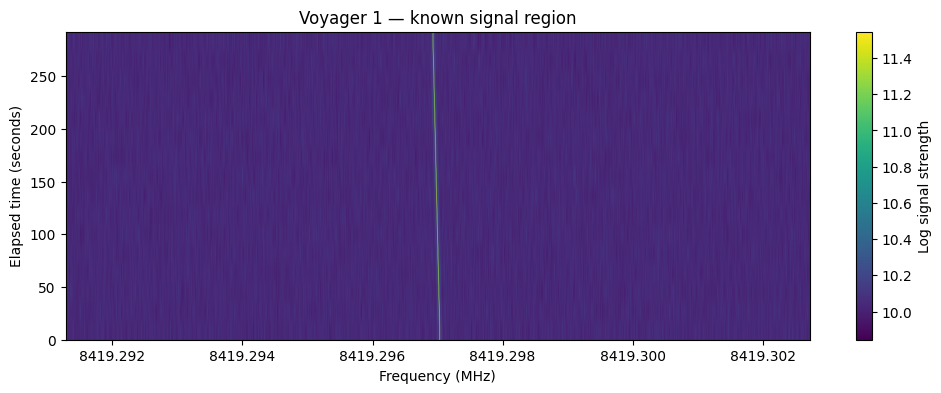

In [18]:
tsamp = wf.header["tsamp"]

total_time = voyager_log_ascending.shape[0] * tsamp

plt.figure(figsize=(12, 4))

plt.imshow(
    voyager_log_ascending,
    aspect="auto",
    origin="lower",
    extent=[
        freqs_ascending[0],
        freqs_ascending[-1],
        0,
        total_time,
    ],
)

plt.xlabel("Frequency (MHz)")
plt.ylabel("Elapsed time (seconds)")
plt.title("Voyager 1 — known signal region")

plt.colorbar(label="Log signal strength")

plt.show()

In [19]:
peak_indices = voyager_log_ascending.argmax(axis=1)
peak_freqs = freqs_ascending[peak_indices]

for i, freq in enumerate(peak_freqs):
    print(f"Time row {i}: {freq:.6f} MHz")

Time row 0: 8419.297028 MHz
Time row 1: 8419.297019 MHz
Time row 2: 8419.297014 MHz
Time row 3: 8419.297006 MHz
Time row 4: 8419.297000 MHz
Time row 5: 8419.296994 MHz
Time row 6: 8419.296989 MHz
Time row 7: 8419.296980 MHz
Time row 8: 8419.296975 MHz
Time row 9: 8419.296966 MHz
Time row 10: 8419.296961 MHz
Time row 11: 8419.296952 MHz
Time row 12: 8419.296947 MHz
Time row 13: 8419.296938 MHz
Time row 14: 8419.296930 MHz
Time row 15: 8419.296924 MHz


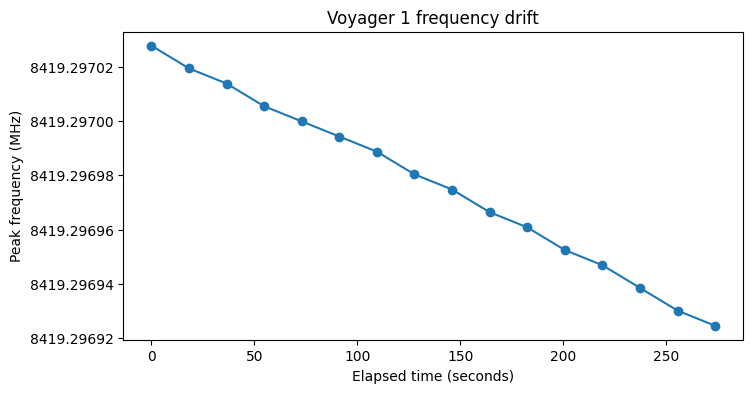

In [20]:
times = np.arange(len(peak_freqs)) * tsamp

plt.figure(figsize=(8, 4))

plt.plot(times, peak_freqs, marker="o")

plt.xlabel("Elapsed time (seconds)")
plt.ylabel("Peak frequency (MHz)")
plt.title("Voyager 1 frequency drift")

plt.show()